# Polygon2d and NestedPolygon2d

UPXO-native 2D polygon classes (`upxo.geoEntities.polygon2d`), built on the
live UPXO boundary stack (`Sline2d` -> `MSline2d` -> `ring2d`) rather than
plain Shapely, while remaining convertible to/from Shapely.

This notebook builds each capability directly and plots the result:

1. A single `Polygon2d`
2. Shapely round trip
3. Editing a shared grain-boundary wall -- an edit on one grain propagates
   to its neighbour automatically, since they hold the same segment object
4. `NestedPolygon2d` -- a grain with a hole
5. `NestedPolygon2d` -- a hole with its own hole (constructed natively;
   Shapely cannot source this case)
6. Feeding into Technique A geometrification (`dtype='upxo'`)
7. Per-grain scalar props -> DataFrame bridge

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from shapely.geometry import Polygon as ShPolygon, MultiPolygon

from upxo.geoEntities.point2d import Point2d
from upxo.geoEntities.sline2d import Sline2d as sl2d
from upxo.geoEntities.mulsline2d import MSline2d, ring2d
from upxo.geoEntities.polygon2d import (
    Polygon2d, NestedPolygon2d,
    polygons_to_prop_dataframe, apply_prop_dataframe,
)
from upxo.viz import gsviz

def as_multipolygon(geom):
    """Normalise a Polygon/MultiPolygon/GeometryCollection difference
    result into a MultiPolygon for plotting."""
    if hasattr(geom, 'geoms'):
        return MultiPolygon([g for g in geom.geoms if g.area > 0])
    return MultiPolygon([geom])

## 1. A single `Polygon2d`

`Polygon2d.from_ring2d` wraps an existing `ring2d` with no copying --
exactly how it plugs into Technique A (`self.GB[gid]` is already a `ring2d`).

area=4.0, perimeter=8.0, centroid=[0.8 0.8]


Text(0.5, 1.0, 'A single Polygon2d')

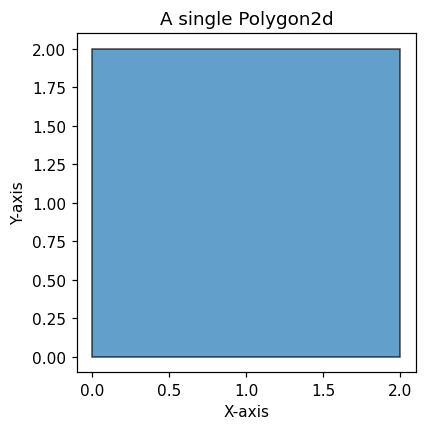

In [2]:
def square_ring(x0=0.0, y0=0.0, s=2.0):
    coords = [(x0, y0), (x0+s, y0), (x0+s, y0+s), (x0, y0+s), (x0, y0)]
    msl = MSline2d.by_coords(coords, close=False)
    return ring2d([msl], segids=[0], segflips=[False])

poly = Polygon2d.from_ring2d(square_ring(0, 0, 2), gid=1)
print(f"area={poly.area}, perimeter={poly.perimeter}, centroid={poly.centroid}")

fig, ax = plt.subplots(figsize=(4, 4), dpi=110)
gsviz.plot_multipolygon_geometric(MultiPolygon([poly.make_shapely()]), fig=fig, ax=ax)
ax.set_title('A single Polygon2d')

## 2. Shapely round trip

`from_shapely_polygon` builds a fresh `ring2d`; `make_shapely` converts back.
Overlay the original (dashed) and the round-tripped shape (filled) -- they
coincide exactly.

area:      original=15.5000  round-tripped=15.5000
perimeter: original=15.8806  round-tripped=15.8806


Text(0.5, 1.0, 'Shapely -> Polygon2d -> Shapely round trip')

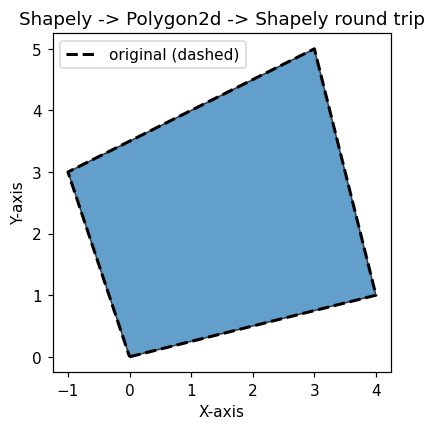

In [3]:
original = ShPolygon([(0, 0), (4, 1), (3, 5), (-1, 3)])
poly2 = Polygon2d.from_shapely_polygon(original, gid=2)
round_tripped = poly2.make_shapely()

print(f"area:      original={original.area:.4f}  round-tripped={round_tripped.area:.4f}")
print(f"perimeter: original={original.length:.4f}  round-tripped={round_tripped.length:.4f}")

fig, ax = plt.subplots(figsize=(4, 4), dpi=110)
gsviz.plot_multipolygon_geometric(MultiPolygon([round_tripped]), fig=fig, ax=ax)
ox, oy = original.exterior.xy
ax.plot(ox, oy, 'k--', lw=2, label='original (dashed)')
ax.legend()
ax.set_title('Shapely -> Polygon2d -> Shapely round trip')

## 3. Editing a shared grain-boundary wall

Two grains, A (left) and B (right), share one wall -- the vertical segment
from (2,0) to (2,2). Both rings reference the *same* `MSline2d` object for
that wall (B traverses it in the opposite direction, `segflips=True`,
exactly how UPXO's real geometrification pipeline handles a shared wall
between two consistently-wound neighbouring grains).

Editing the wall via grain A's `Polygon2d` mutates that shared object in
place -- grain B's shape updates automatically, with no second edit and no
gap or overlap at the interface.

before: area A=4.000, area B=4.000
after:  area A=4.600, area B=3.400
shared wall coords, read from B's own segment list: [[2.0, 0.0], [2.6, 1.0], [2.0, 2.0]]


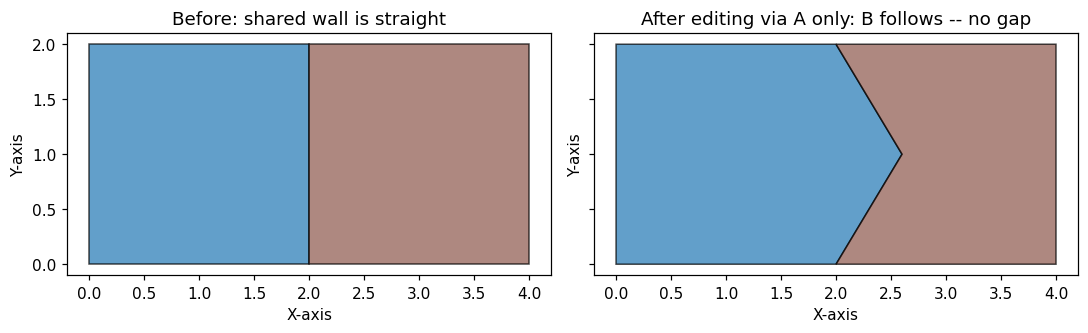

In [4]:
def msl(coords):
    lines = [sl2d(coords[i][0], coords[i][1], coords[i+1][0], coords[i+1][1])
            for i in range(len(coords) - 1)]
    return MSline2d.from_lines(lines, close=False)

shared = msl([(2, 0), (2, 1), (2, 2)])          # the wall grain A and grain B share

segA0 = msl([(0, 0), (2, 0)])                    # A's bottom edge
segA2 = msl([(2, 2), (0, 2), (0, 0)])            # A's top + left edge
ring_A = ring2d([segA0, shared, segA2], segids=[0, 1, 2], segflips=[False, False, False])

segB0 = msl([(2, 0), (4, 0)])                    # B's bottom edge
segB1 = msl([(4, 0), (4, 2), (2, 2)])            # B's right + top edge
ring_B = ring2d([segB0, segB1, shared], segids=[0, 1, 2], segflips=[False, False, True])

poly_A = Polygon2d.from_ring2d(ring_A, gid=1)
poly_B = Polygon2d.from_ring2d(ring_B, gid=2)

assert poly_A.ring.segments[1] is poly_B.ring.segments[2] is shared
print(f"before: area A={poly_A.area:.3f}, area B={poly_B.area:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=110, sharex=True, sharey=True)
gsviz.plot_multipolygon_geometric(
    MultiPolygon([poly_A.make_shapely(), poly_B.make_shapely()]), fig=fig, ax=axes[0])
axes[0].set_title('Before: shared wall is straight')

# Edit the shared wall via grain A only -- bulge its midpoint into grain B.
poly_A.edit_segment(1, [(2, 0), (2.6, 1), (2, 2)])

gsviz.plot_multipolygon_geometric(
    MultiPolygon([poly_A.make_shapely(), poly_B.make_shapely()]), fig=fig, ax=axes[1])
axes[1].set_title('After editing via A only: B follows -- no gap')
fig.tight_layout()

print(f"after:  area A={poly_A.area:.3f}, area B={poly_B.area:.3f}")
print(f"shared wall coords, read from B's own segment list: "
     f"{poly_B.ring.segments[2].get_node_coords().tolist()}")

## 4. `NestedPolygon2d` -- a grain with a hole

One level of nesting round-trips through Shapely directly (`poly.interiors`
are always simple rings). `gsviz.plot_multipolygon_geometric` draws the
hole as a true cut-out, not an opaque patch.

host area=100, hole area=4, net area=96.0
hole is a flat Polygon2d: ['Polygon2d']


Text(0.5, 1.0, 'NestedPolygon2d: one grain, one hole')

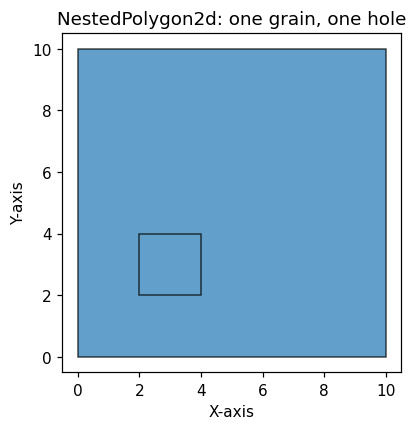

In [5]:
shell = [(0, 0), (10, 0), (10, 10), (0, 10)]
hole = [(2, 2), (4, 2), (4, 4), (2, 4)]
shp_with_hole = ShPolygon(shell, holes=[hole])

grain_with_hole = NestedPolygon2d.from_shapely_polygon(shp_with_hole, gid=3)
print(f"host area=100, hole area=4, net area={grain_with_hole.area}")
print(f"hole is a flat Polygon2d: {[type(h).__name__ for h in grain_with_hole.holes]}")

fig, ax = plt.subplots(figsize=(4, 4), dpi=110)
gsviz.plot_multipolygon_geometric(as_multipolygon(grain_with_hole.make_shapely()), fig=fig, ax=ax)
ax.set_title('NestedPolygon2d: one grain, one hole')

## 5. `NestedPolygon2d` -- a hole with its own hole

Shapely has no native type for this (an interior ring cannot itself have
holes), so this can only be *constructed*, not round-tripped from a Shapely
polygon. `make_shapely()` falls back to boolean composition
(`host.difference(union(holes))`) whenever any hole is itself a
`NestedPolygon2d`.

Geometrically, the result is genuinely a `MultiPolygon`: the annular band
left after subtracting a donut-shaped hole from the outer host, plus the
island at the donut's own centre -- which is exactly the correct topology
for "a void with an inclusion inside it".

gids (outer, hole, innermost): [4, 5, 6]
area: computed=68.0, hand-expected=68.0
make_shapely() result type: MultiPolygon, 2 part(s)


Text(0.5, 1.0, 'Hole-in-hole: annular band + island at the centre')

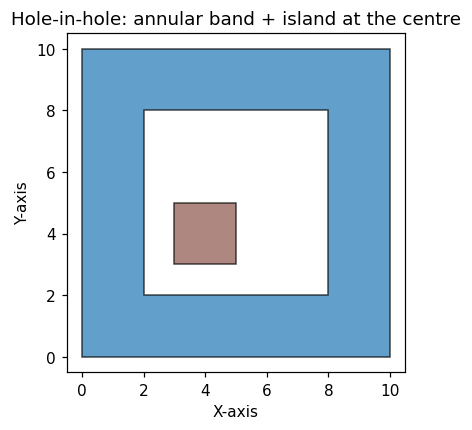

In [6]:
outer_host = Polygon2d.from_ring2d(square_ring(0, 0, 10), gid=4)
inner_hole_host = Polygon2d.from_ring2d(square_ring(2, 2, 6), gid=5)
innermost_hole = Polygon2d.from_ring2d(square_ring(3, 3, 2), gid=6)

hole_with_its_own_hole = NestedPolygon2d(host=inner_hole_host, holes=[innermost_hole], gid=5)
outer = NestedPolygon2d(host=outer_host, holes=[hole_with_its_own_hole], gid=4)

expected_area = 100.0 - (36.0 - 4.0)
print(f"gids (outer, hole, innermost): {outer.gids_all}")
print(f"area: computed={outer.area}, hand-expected={expected_area}")

result = outer.make_shapely()
print(f"make_shapely() result type: {type(result).__name__}, "
     f"{len(result.geoms) if hasattr(result, 'geoms') else 1} part(s)")

fig, ax = plt.subplots(figsize=(4, 4), dpi=110)
gsviz.plot_multipolygon_geometric(as_multipolygon(result), fig=fig, ax=ax)
ax.set_title('Hole-in-hole: annular band + island at the centre')

## 6. Feeding into Technique A geometrification (`dtype='upxo'`)

`construct_geometric_xtals_from_gbcoords(..., dtype='upxo')` wraps each
grain's already-built `ring2d` (`self.GB[gid]`) into a `Polygon2d`, with no
rebuild -- a drop-in alternative to the default `dtype='shapely'` path.

grain 1: type=Polygon2d, area(upxo)=12.0000, area(shapely)=12.0000
grain 2: type=Polygon2d, area(upxo)=12.0000, area(shapely)=12.0000


Text(0.5, 1.0, "Technique A grains, built via dtype='upxo'")

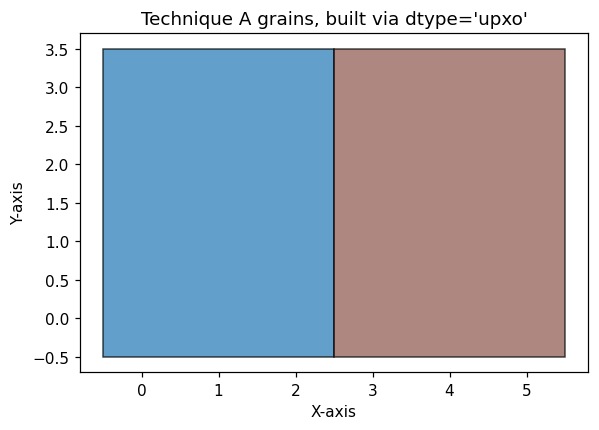

In [7]:
from upxo.pxtal.geometrification import polygonised_grain_structure

lgi = np.array([
    [1, 1, 1, 2, 2, 2],
    [1, 1, 1, 2, 2, 2],
    [1, 1, 1, 2, 2, 2],
    [1, 1, 1, 2, 2, 2],
], dtype=np.int32)

gs = polygonised_grain_structure(lgi, np.unique(lgi), None)
gs.pix_to_geom(verbose=False)

shapely_grains = gs.construct_geometric_xtals_from_gbcoords(gs.GBCoords, dtype='shapely', saa=False, throw=True)
upxo_grains = gs.construct_geometric_xtals_from_gbcoords(gs.GBCoords, dtype='upxo', saa=False, throw=True)

for gid in upxo_grains:
    print(f"grain {gid}: type={type(upxo_grains[gid]).__name__}, "
         f"area(upxo)={upxo_grains[gid].area:.4f}, area(shapely)={shapely_grains[gid].area:.4f}")

fig, ax = plt.subplots(figsize=(6, 4), dpi=110)
gsviz.plot_multipolygon_geometric(
    MultiPolygon([p.make_shapely() for p in upxo_grains.values()]), fig=fig, ax=ax)
ax.set_title("Technique A grains, built via dtype='upxo'")

## 7. Per-grain scalar props -> DataFrame bridge

`.props` is an open per-`Polygon2d` dict; `polygons_to_prop_dataframe` /
`apply_prop_dataframe` bridge it to UPXO's usual per-grain scalar
convention -- a `gid - 1`-indexed `pandas.DataFrame`, one column per
property, matching `pxtal.mcgs2_temporal_slice`'s `self.prop`.

In [8]:
for gid, p in upxo_grains.items():
    p.props['area'] = p.area
    p.props['phase'] = 1

df = polygons_to_prop_dataframe(upxo_grains)
df

,area,phase
0,12.0,1
1,12.0,1
